--- First 5 Rows ---
   sepal_length  sepal_width  petal_length  petal_width  species_code species
0           5.1          3.5           1.4          0.2             0  setosa
1           4.9          3.0           1.4          0.2             0  setosa
2           4.7          3.2           1.3          0.2             0  setosa
3           4.6          3.1           1.5          0.2             0  setosa
4           5.0          3.6           1.4          0.2             0  setosa

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_code    0
species         0
dtype: int64

--- Summary Statistics ---
       sepal_length  sepal_width  petal_length  petal_width  species_code
count    150.000000   150.000000    150.000000   150.000000    150.000000
mean       5.843333     3.057333      3.758000     1.199333      1.000000
std        0.828066     0.435866      1.765298     0.762238      0.819232
min        4.300000     2.000000      1.00

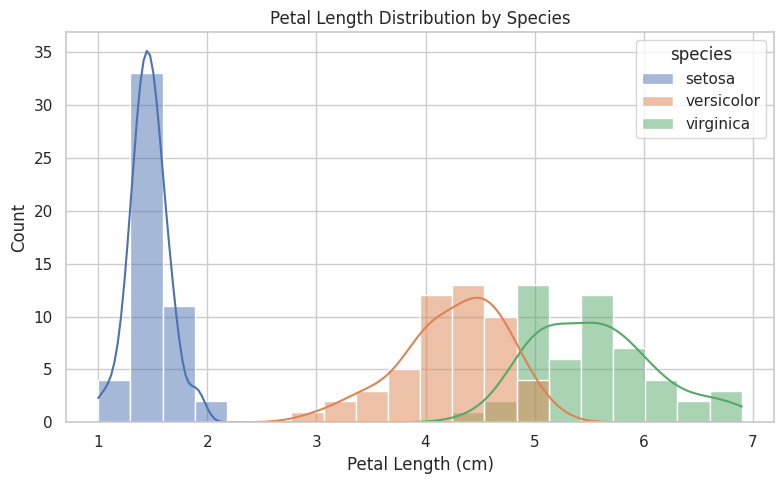

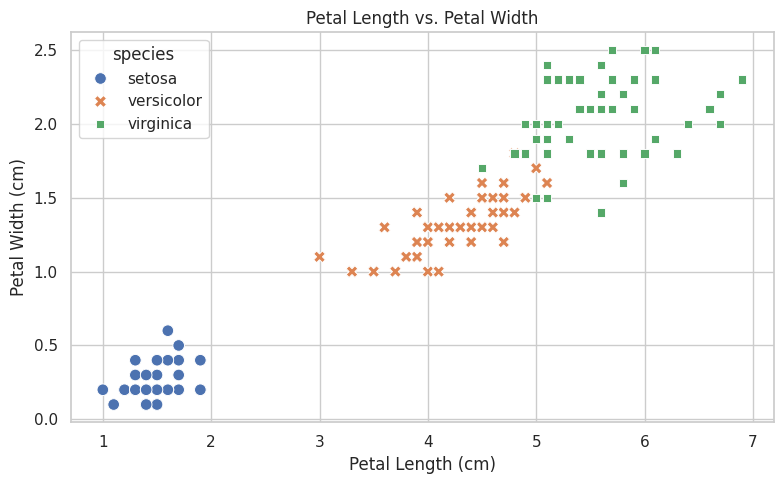

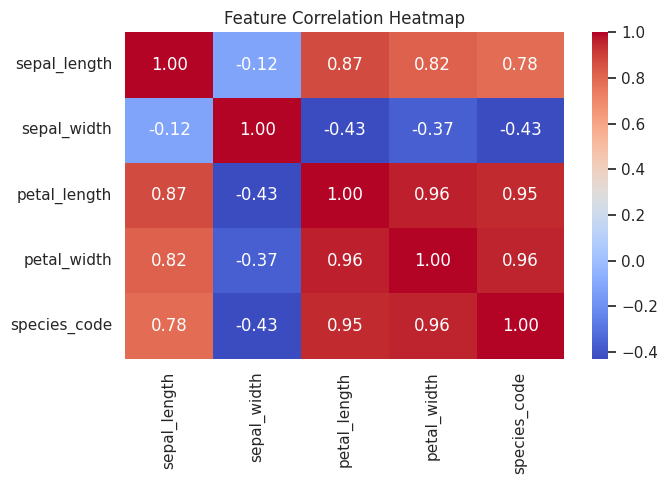

In [1]:
# --- STEP 1: Import Libraries ---
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

# --- STEP 2: Load and Prepare Dataset ---
iris_data = load_iris(as_frame=True)
df = iris_data.frame

# Rename columns for clarity
df.columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species_code',
]
df['species'] = df['species_code'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
)

# --- STEP 3: Data Inspection & Statistics ---
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

# --- STEP 4: Visualizations ---
sns.set_theme(style="whitegrid")

# 1. Feature Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="petal_length", hue="species", kde=True, bins=20)
plt.title("Petal Length Distribution by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("petal_distribution.png")
plt.show()

# 2. Relationship Analysis (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    style="species",
    s=70,
)
plt.title("Petal Length vs. Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.savefig("petal_scatter.png")
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(7, 5))
numeric_df = df.drop(columns=["species"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()